# Импорт

In [ ]:
! apt-get install -qq -y quantum-espresso
! pip install -q ase

In [2]:
! apt-get install -qq -y zip > /dev/null 2>&1

In [3]:
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk
from ase.io import write, read
from ase.calculators.espresso import Espresso, EspressoProfile

In [4]:
from google.colab import files

# Функции расчёта

In [5]:
def relax(structure, prefix, input_data, pseudopotentials, kpts):
    outdir = f'./tmp_{prefix}'
    os.makedirs(outdir, exist_ok=True)
    calc = Espresso(
        profile=EspressoProfile(command='pw.x', pseudo_dir=os.path.abspath('.')),
        prefix=prefix,
        pseudopotentials=pseudopotentials,
        kpts=kpts,
        input_data=input_data,
        outdir=outdir,
    )
    structure.calc = calc
    energy = structure.get_potential_energy()
    os.replace('espresso.pwi', f'{prefix}/{prefix}.pw.in')
    os.replace('espresso.pwo', f'{prefix}/result/{prefix}.pw.out')
    os.replace('espresso.err', f'{prefix}/result/{prefix}.pw.err')
    print(f'{prefix}: E = {energy:.6f} eV')
    return structure

In [6]:
def nscf(structure, prefix, input_data, pseudopotentials, kpts, degauss=None):
    outdir = f'./tmp_{prefix}'
    os.makedirs(outdir, exist_ok=True)
    input_data_nscf = {k: dict(v) for k, v in input_data.items()}
    input_data_nscf['control']['calculation'] = 'nscf'
    input_data_nscf.pop('ions', None)
    input_data_nscf.pop('cell', None)
    if degauss is not None:
        input_data_nscf['system']['degauss'] = degauss

    calc = Espresso(
        profile=EspressoProfile(command='pw.x', pseudo_dir=os.path.abspath('.')),
        prefix=prefix,
        pseudopotentials=pseudopotentials,
        kpts=kpts,
        input_data=input_data_nscf,
        outdir=outdir,
    )
    calc.write_inputfiles(structure, properties=['energy'])

    infile = f'{prefix}/{prefix}_nscf.in'
    outfile = f'{prefix}/result/{prefix}_nscf.out'
    errfile = f'{prefix}/result/{prefix}_nscf.err'
    os.replace('espresso.pwi', infile)
    os.system(f'pw.x < {infile} > {outfile} 2> {errfile}')

    with open(outfile) as f:
        lines = f.read()
    if 'JOB DONE' not in lines:
        print(f'!!! pw.x не завершил nscf ({prefix})')
        for l in lines.splitlines():
            if 'Error' in l or 'error' in l:
                print(l)
        print('--- последние строки вывода ---')
        print('\n'.join(lines.splitlines()[-15:]))
        return None
    print(f'{prefix} (nscf): готов')
    return structure


In [7]:
def run_projwfc(prefix, outdir, degauss=0.015, Emin=-10.0, Emax=20.0, DeltaE=0.01):
    infile = f'{prefix}/{prefix}_projwfc.in'
    outfile = f'{prefix}/result/{prefix}_projwfc.out'
    projwfc_in = f'''
&PROJWFC
  prefix  = '{prefix}'
  outdir  = '{outdir}'
  ngauss  = 1
  degauss = {degauss}
  Emin    = {Emin}
  Emax    = {Emax}
  DeltaE  = {DeltaE}
/
'''
    with open(infile, 'w') as f:
        f.write(projwfc_in)
    os.system(f'projwfc.x < {infile} > {outfile}')
    for f in glob.glob(f'{prefix}.pdos_*'):
        os.replace(f, f'{prefix}/result/{f}')
    if os.path.exists(f'{prefix}.pdos_tot'):
        os.replace(f'{prefix}.pdos_tot', f'{prefix}/result/{prefix}.pdos_tot')
    print(f'{prefix}: projwfc готов')

In [8]:
def get_fermi_energy_from_nscf(prefix):
    outfile = f'{prefix}/result/{prefix}_nscf.out'
    with open(outfile) as f:
        for line in f:
            if 'the Fermi energy is' in line:
                return float(line.split()[-2])
    return None

# Структуры

In [9]:
Al_start = bulk('Al', 'fcc', a=4.05, cubic=True)
Ni_start = bulk('Ni', 'fcc', a=3.52, cubic=True)

In [10]:
a = 3.57
Ni3Al_start = Atoms('AlNi3', positions=[(0,0,0)]*4, cell=[a,a,a], pbc=True)
Ni3Al_start.set_scaled_positions([(0,0,0), (0.5,0,0.5), (0.5,0.5,0), (0,0.5,0.5)])

# Псевдопотенциалы

In [11]:
if not os.path.exists('Al.pbe-n-kjpaw_psl.1.0.0.UPF'):
    !wget -q http://pseudopotentials.quantum-espresso.org/upf_files/Al.pbe-n-kjpaw_psl.1.0.0.UPF
if not os.path.exists('Ni.pbe-spn-kjpaw_psl.1.0.0.UPF'):
    !wget -q http://pseudopotentials.quantum-espresso.org/upf_files/Ni.pbe-spn-kjpaw_psl.1.0.0.UPF

PBE_ps = {'Ni': 'Ni.pbe-spn-kjpaw_psl.1.0.0.UPF',
          'Al': 'Al.pbe-n-kjpaw_psl.1.0.0.UPF'}

# Параметры расчёта

In [12]:
kpts = (8, 8, 8)          # для relax
kpts_nscf = {'Ni': (18, 18, 18), 'Al': (16, 16, 16), 'Ni3Al': (18, 18, 18)}  # для nscf (плотность k-сетки как у VASP KSPACING=0.10)
degauss = 0.015
degauss_nscf = 0.01

electron_settings = {
    'conv_thr': 1e-8,
    'mixing_mode': 'local-TF',
    'mixing_beta': 0.7,
    'mixing_ndim': 8,
    'diagonalization': 'david',
    'diago_david_ndim': 6,
}

In [13]:
input_data_Al = {
    'control': {'calculation': 'relax', 'restart_mode': 'from_scratch',
                'prefix': 'Al', 'tstress': True, 'tprnfor': True},
    'system': {'ecutwfc': 40, 'ecutrho': 200, 'nspin': 1,
               'occupations': 'smearing', 'smearing': 'methfessel-paxton',
               'degauss': degauss, 'input_dft': 'pbe'},
    'electrons': electron_settings,
    'ions': {'ion_dynamics': 'bfgs'},
    'cell': {'cell_dynamics': 'bfgs', 'press_conv_thr': 0.1},
}

In [14]:
input_data_Ni = {
    'control': {'calculation': 'relax', 'restart_mode': 'from_scratch',
                'prefix': 'Ni', 'tstress': True, 'tprnfor': True},
    'system': {'ecutwfc': 80, 'ecutrho': 500, 'nspin': 2,
               'starting_magnetization(1)': 0.6,
               'occupations': 'smearing', 'smearing': 'methfessel-paxton',
               'degauss': degauss, 'input_dft': 'pbe'},
    'electrons': electron_settings,
    'ions': {'ion_dynamics': 'bfgs'},
    'cell': {'cell_dynamics': 'bfgs', 'press_conv_thr': 0.1},
}

In [15]:
input_data_Ni3Al = {
    'control': {'calculation': 'relax', 'restart_mode': 'from_scratch',
                'prefix': 'Ni3Al', 'tstress': True, 'tprnfor': True},
    'system': {'ecutwfc': 80, 'ecutrho': 500, 'nspin': 2,
               'starting_magnetization(1)': 0.0,
               'starting_magnetization(2)': 0.2,
               'occupations': 'smearing', 'smearing': 'methfessel-paxton',
               'degauss': degauss, 'input_dft': 'pbe'},
    'electrons': electron_settings,
    'ions': {'ion_dynamics': 'bfgs'},
    'cell': {'cell_dynamics': 'bfgs', 'press_conv_thr': 0.1},
}

In [16]:
for prefix in ['Al', 'Ni', 'Ni3Al']:
    os.makedirs(f'{prefix}/result', exist_ok=True)

# Relax

In [17]:
Ni_opt = relax(Ni_start.copy(), 'Ni', input_data_Ni, PBE_ps, kpts)

Ni: E = -23355.944571 eV


In [18]:
Al_opt = relax(Al_start.copy(), 'Al', input_data_Al, PBE_ps, kpts)

Al: E = -2149.865585 eV


In [19]:
Ni3Al_opt = relax(Ni3Al_start.copy(), 'Ni3Al', input_data_Ni3Al, PBE_ps, kpts)

Ni3Al: E = -18056.123865 eV


In [20]:
write('Al/result/Al_opt.cif', Al_opt)
write('Ni/result/Ni_opt.cif', Ni_opt)
write('Ni3Al/result/Ni3Al_opt.cif', Ni3Al_opt)

# NSCF

In [21]:
Ni_nscf = nscf(Ni_opt, 'Ni', input_data_Ni, PBE_ps, kpts_nscf['Ni'], degauss=degauss_nscf)

Ni (nscf): готов


In [22]:
Al_nscf = nscf(Al_opt, 'Al', input_data_Al, PBE_ps, kpts_nscf['Al'], degauss=degauss_nscf)

Al (nscf): готов


In [23]:
Ni3Al_nscf = nscf(Ni3Al_opt, 'Ni3Al', input_data_Ni3Al, PBE_ps, kpts_nscf['Ni3Al'], degauss=degauss_nscf)

Ni3Al (nscf): готов


# DOS (projwfc.x)

In [24]:
run_projwfc('Ni', './tmp_Ni', degauss=degauss_nscf, Emin=-15, Emax=25, DeltaE=0.005)
run_projwfc('Al', './tmp_Al', degauss=degauss_nscf, Emin=-15, Emax=25, DeltaE=0.005)
run_projwfc('Ni3Al', './tmp_Ni3Al', degauss=degauss_nscf, Emin=-15, Emax=25, DeltaE=0.005)

Ni: projwfc готов
Al: projwfc готов
Ni3Al: projwfc готов


# Энергия Ферми

In [25]:
fermi_Ni = get_fermi_energy_from_nscf('Ni')
fermi_Al = get_fermi_energy_from_nscf('Al')
fermi_Ni3Al = get_fermi_energy_from_nscf('Ni3Al')

print(f"E_F (Ni)   = {fermi_Ni:.4f} eV")
print(f"E_F (Al)   = {fermi_Al:.4f} eV")
print(f"E_F (Ni3Al)= {fermi_Ni3Al:.4f} eV")

E_F (Ni)   = 17.9453 eV
E_F (Al)   = 7.8425 eV
E_F (Ni3Al)= 15.4906 eV


# DOS (график)

In [26]:
def load_dos(prefix):
    data = np.loadtxt(f'{prefix}/result/{prefix}.pdos_tot')
    e = data[:, 0]
    if data.shape[1] > 2:
        dos = data[:, 1] + data[:, 2]
    else:
        dos = data[:, 1]
    return e, dos

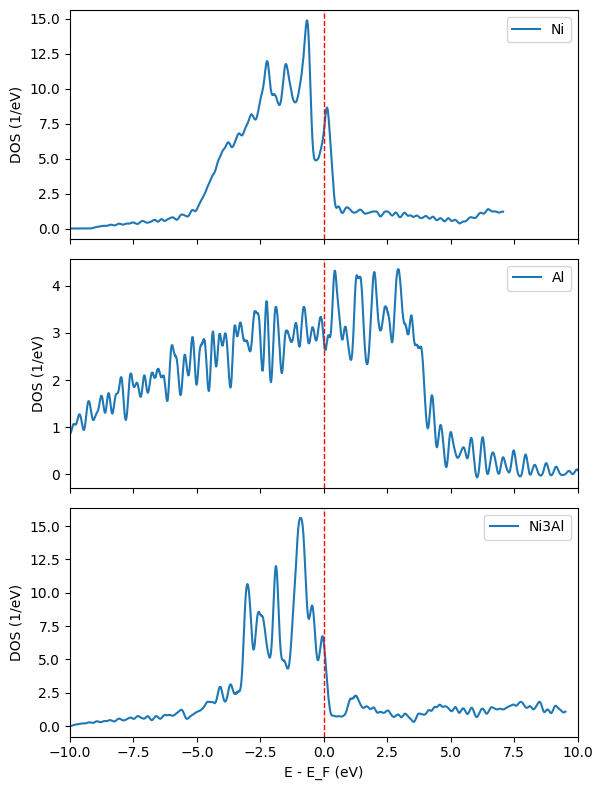

In [27]:
e_Ni, dos_Ni = load_dos('Ni')
e_Al, dos_Al = load_dos('Al')
e_Ni3Al, dos_Ni3Al = load_dos('Ni3Al')

fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(e_Ni - fermi_Ni, dos_Ni, label='Ni')
axes[0].axvline(0, color='r', ls='--', lw=1)
axes[0].set_ylabel('DOS (1/eV)')
axes[0].legend()

axes[1].plot(e_Al - fermi_Al, dos_Al, label='Al')
axes[1].axvline(0, color='r', ls='--', lw=1)
axes[1].set_ylabel('DOS (1/eV)')
axes[1].legend()

axes[2].plot(e_Ni3Al - fermi_Ni3Al, dos_Ni3Al, label='Ni3Al')
axes[2].axvline(0, color='r', ls='--', lw=1)
axes[2].set_xlabel('E - E_F (eV)')
axes[2].set_ylabel('DOS (1/eV)')
axes[2].legend()

plt.xlim(-10, 10)
plt.tight_layout()
plt.show()

In [28]:
for prefix in ['Al', 'Ni', 'Ni3Al']:
    shutil.copy(f'tmp_{prefix}/{prefix}.save/data-file-schema.xml', f'{prefix}/result/data-file-schema.xml')
    shutil.copy(f'tmp_{prefix}/{prefix}.xml', f'{prefix}/result/{prefix}.xml')

# Скачивание результатов

In [29]:
! ls

Al			      Ni3Al			      tmp_Al
Al.pbe-n-kjpaw_psl.1.0.0.UPF  Ni.pbe-spn-kjpaw_psl.1.0.0.UPF  tmp_Ni
Ni			      sample_data		      tmp_Ni3Al


In [30]:
! zip -r QE_results_nscf.zip Al/ Ni/ Ni3Al/ 2>/dev/null

files.download('QE_results_nscf.zip')

  adding: Al/ (stored 0%)
  adding: Al/Al_projwfc.in (deflated 24%)
  adding: Al/Al.pw.in (deflated 59%)
  adding: Al/result/ (stored 0%)
  adding: Al/result/Al.pdos_atm#3(Al)_wfc#2(p) (deflated 84%)
  adding: Al/result/Al.pw.out (deflated 73%)
  adding: Al/result/Al.pw.err (stored 0%)
  adding: Al/result/Al_nscf.err (stored 0%)
  adding: Al/result/data-file-schema.xml (deflated 82%)
  adding: Al/result/Al.pdos_atm#4(Al)_wfc#2(p) (deflated 84%)
  adding: Al/result/Al.pdos_atm#2(Al)_wfc#2(p) (deflated 84%)
  adding: Al/result/Al.pdos_atm#3(Al)_wfc#1(s) (deflated 81%)
  adding: Al/result/Al.pdos_atm#4(Al)_wfc#1(s) (deflated 81%)
  adding: Al/result/Al.pdos_atm#1(Al)_wfc#1(s) (deflated 81%)
  adding: Al/result/Al.pdos_atm#2(Al)_wfc#1(s) (deflated 81%)
  adding: Al/result/Al_nscf.out (deflated 64%)
  adding: Al/result/Al.xml (deflated 82%)
  adding: Al/result/Al_projwfc.out (deflated 89%)
  adding: Al/result/Al.pdos_tot (deflated 81%)
  adding: Al/result/Al_opt.cif (deflated 62%)
  adding:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>